In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import random

# URLs and categories
url = [
    "https://www.banggood.com/Wholesale-Electronics-ca-2001.html",
    "https://www.banggood.com/Wholesale-Sports-and-Outdoors-ca-6001.html",
    "https://www.banggood.com/Wholesale-Automobiles-and-Motorcycles-ca-4001.html",
    "https://www.banggood.com/Wholesale-Computers-and-Office-ca-5001.html",
    "https://www.banggood.com/Wholesale-Tools,Industrial-and-Scientific-ca-3001.html"
]

category = ["Electronics", "Sports and Outdoors", "Automobiles and Motorcycles", "Computers and Office", "Tools, Industrial and Scientific"]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

All_products = []

# Scraping
for link, cat in zip(url, category):
    response = requests.get(link, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    products = soup.find_all("li", class_="product-item")

    for p in products:
        title_tag = p.find("div", class_="text")
        title = title_tag.get_text(strip=True) if title_tag else "N/A"

        price_tag = p.find("div", class_="price")
        price = price_tag.get_text(strip=True) if price_tag else "N/A"

        img_tag = p.find("img")
        img = img_tag["data-src"] if img_tag and img_tag.has_attr("data-src") else (img_tag["src"] if img_tag else "N/A")

        link_tag = p.find("a")
        link = link_tag["href"] if link_tag else "N/A"

       
        rating = round(random.uniform(3.0, 5.0), 1)
        review_count = random.randint(0, 500)
        availability = "In Stock"

        All_products.append({
            "title": title,
            "price": price,
            "img": img,
            "link": link,
            "category": cat,
            "rating": rating,
            "review_count":review_count,
            "availability": availability
        })

# Create DataFrame
df = pd.DataFrame(All_products)
df.to_csv("banggood_products_with_category_raw.csv", index=False)

# Cleaning
df.drop_duplicates(subset=["title", "link"], inplace=True)
df.replace("N/A", pd.NA, inplace=True)
df.dropna(subset=["title", "link"], inplace=True)

# Clean price
def clean_price(price_str):
    if pd.isna(price_str):
        return pd.NA
    price_str = re.sub(r"[^\d\.]", "", price_str)
    try:
        return float(price_str)
    except:
        return pd.NA

df["price"] = df["price"].apply(clean_price)

# Strip whitespaces
df["title"] = df["title"].str.strip()
df["category"] = df["category"].str.strip()

# Reset index
df.reset_index(drop=True, inplace=True)

# Save cleaned CSV
df.to_csv("banggood_products_with_category_clean.csv", index=False)

print("Cleaning complete! Total products:", len(df))


Cleaning complete! Total products: 120


In [2]:
df.head(30)

,title,price,img,link,category,rating,review_count,availability
0,Signal Amplifier 100k-6GHz Full Band Low Noise...,10.06,https://imgaz2.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/Signal-Amplifier-100k...,Electronics,4.3,378,In Stock
1,JYETech DSO183 DIY Oscilloscope Kit 500KHz ADC...,12.21,https://imgaz3.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/JYETech-DSO183-DIY-Os...,Electronics,4.3,244,In Stock
2,Donut AM MW/SW Mini Loop Antenna+High Resistan...,22.22,https://imgaz2.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/Donut-AM-MW-or-SW-Min...,Electronics,3.6,125,In Stock
3,Hohem M7 iSteady M7 Cell Phone Gimbal Stabiliz...,205.15,https://imgaz2.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/Hohem-M7-iSteady-M7-C...,Electronics,4.2,277,In Stock
4,KEWEISI KWS-1902L Type-C Tester 4-30V 0-8A Pow...,7.42,https://imgaz3.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/KEWEISI-KWS-1902L-Typ...,Electronics,3.8,23,In Stock
5,AMNVOLT ATR1000 1000W 1.8-30MHz Automatic Ante...,232.24,https://imgaz3.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/AMNVOLT-ATR1000-1000W...,Electronics,3.6,350,In Stock
6,5Pcs LM2596 DC-DC Voltage Regulator Adjustable...,8.51,https://imgaz2.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/5Pcs-LM2596-DC-DC-Vol...,Electronics,3.3,24,In Stock
7,XY6020L 6-70V CNC Adjustable Stabilized Voltag...,6.96,https://imgaz1.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/XY6020L-6-70V-CNC-Adj...,Electronics,4.8,422,In Stock
8,LILYGO® T-Deck Pro ESP32-S3 Development Board ...,89.02,https://imgaz2.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/LILYGO-T-Deck-Pro-ESP...,Electronics,4.9,493,In Stock
9,6 Digits DIY Clock Kit Auto Display Time DIY A...,7.73,https://imgaz2.staticbg.com/thumb/view/oauploa...,https://www.banggood.com/6-Digits-DIY-Clock-Ki...,Electronics,4.6,486,In Stock


## Step 3 Expolatory Analysis

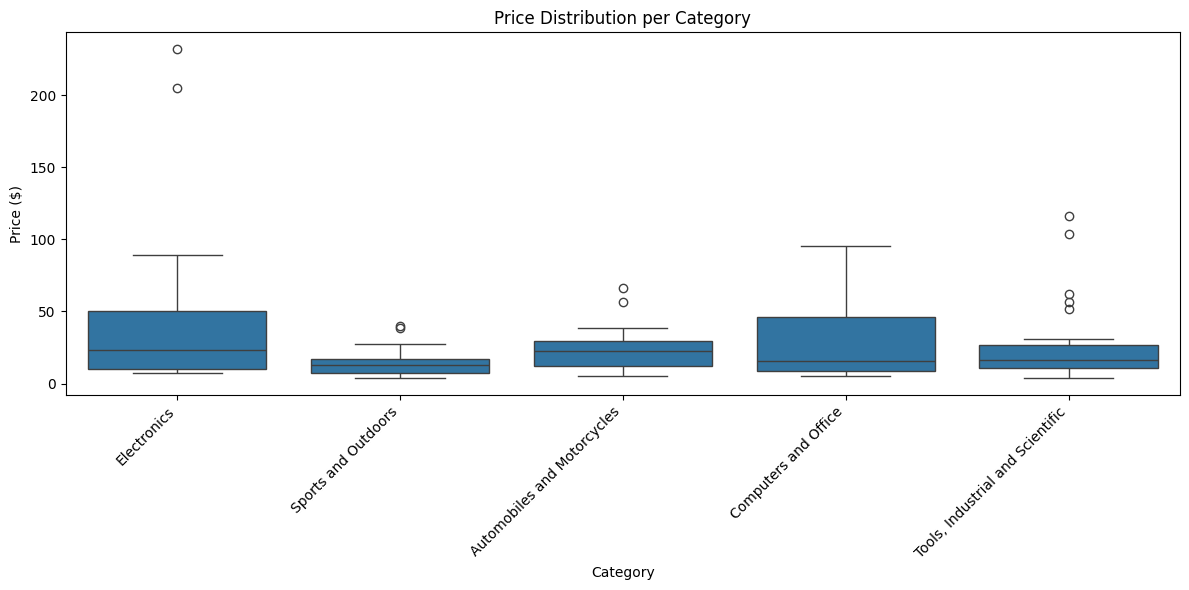

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned CSV
df = pd.read_csv("banggood_products_with_category_clean.csv")

# Ensure numeric columns are correct types
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["review_count"] = pd.to_numeric(df["review_count"], errors="coerce")

# ---- Analysis 1: Price distribution per category ----
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="category", y="price")
plt.xticks(rotation=45, ha='right')
plt.title("Price Distribution per Category")
plt.ylabel("Price ($)")
plt.xlabel("Category")
plt.tight_layout()
plt.show()



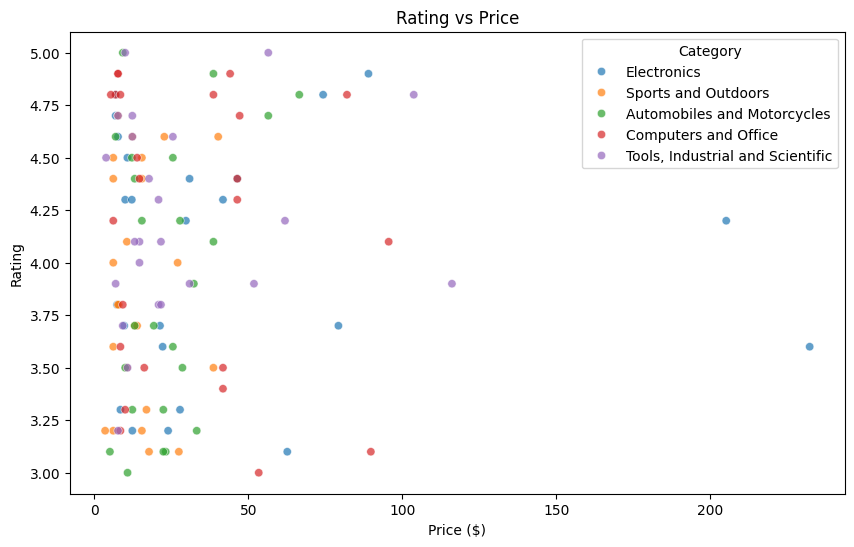

Correlation between price and rating: 0.04


In [4]:
# ---- Analysis 2: Rating vs Price correlation ----
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="price", y="rating", hue="category", alpha=0.7)
plt.title("Rating vs Price")
plt.xlabel("Price ($)")
plt.ylabel("Rating")
plt.legend(title="Category")
plt.show()

# Compute correlation coefficient
correlation = df["price"].corr(df["rating"])
print(f"Correlation between price and rating: {correlation:.2f}")


In [5]:
# ---- Analysis 3: Top reviewed products ----
top_reviewed = df.sort_values(by="review_count", ascending=False).head(10)
print("\nTop 10 reviewed products:")
print(top_reviewed[["title", "category", "review_count", "price", "rating"]])





Top 10 reviewed products:
                                                 title  \
92   JOMAA Tri-mode Touch Control Panel Gesture Tra...   
8    LILYGO® T-Deck Pro ESP32-S3 Development Board ...   
49   Sunbuck AV-660BT 2000W bluetooth 5.0 Audio Pow...   
107  ENJOYWOOD One Way Bearing Roller Feeder Clear ...   
9    6 Digits DIY Clock Kit Auto Display Time DIY A...   
98   ENJOYWOOD Trimming Router Base Trimming Machin...   
65   200W High Power Car Inverter Charger 12V To 11...   
29   IPRee 16 In 1 Multifunctional Hammer Survival ...   
74   UGREEN CM841 for Mac Mini 11-in-1 Docking Stat...   
115  HONGDUI KM-17 Pro Router Plane Die Steel Body ...   

                             category  review_count   price  rating  
92               Computers and Office           494   38.70     4.8  
8                         Electronics           493   89.02     4.9  
49        Automobiles and Motorcycles           493   23.22     3.1  
107  Tools, Industrial and Scientific           492   

In [6]:
# ---- Analysis 4: Best value metric per category ----
# Define 'value' as rating per dollar
df["value_metric"] = df["rating"] / df["price"]
best_value = df.groupby("category").apply(lambda x: x.loc[x["value_metric"].idxmax()])
print("\nBest value product per category (highest rating per $):")
print(best_value[["title", "category", "price", "rating", "value_metric"]])




Best value product per category (highest rating per $):
                                                                              title  \
category                                                                              
Automobiles and Motorcycles       75mm/90mm 1m Heater Duct Hose Hot Cold Air Hea...   
Computers and Office              Microdrive Class 10 High Speed TF Memory Card ...   
Electronics                       XY6020L 6-70V CNC Adjustable Stabilized Voltag...   
Sports and Outdoors               Anti-theft Lock For Electric Scooter Xiaomi Mi...   
Tools, Industrial and Scientific  Drillpro Machinist Square 90º Right Angle Engi...   

                                                          category  price  \
category                                                                    
Automobiles and Motorcycles            Automobiles and Motorcycles   6.96   
Computers and Office                          Computers and Office   5.41   
Electronics              

C:\Users\ADVANCES--PC\AppData\Local\Temp\ipykernel_17956\1959354907.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_value = df.groupby("category").apply(lambda x: x.loc[x["value_metric"].idxmax()])


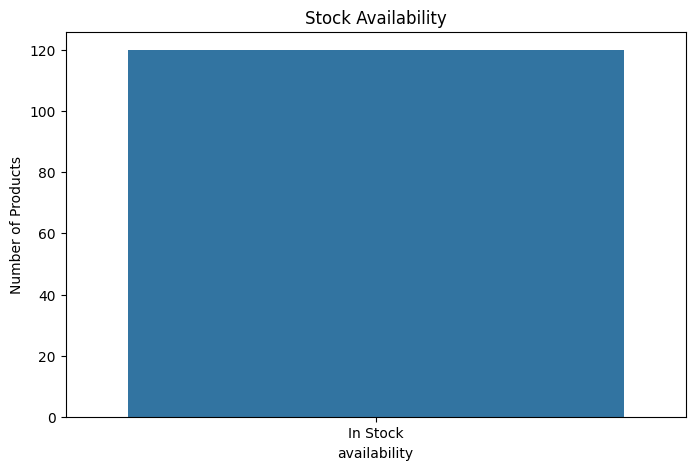

In [7]:
# ---- Analysis 5: Stock availability analysis ----
# Since all products are "In Stock" in your dataset, let's visualize review count per availability
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="availability")
plt.title("Stock Availability")
plt.ylabel("Number of Products")
plt.show()

## Part 4: Load Data into SQL Server

In [15]:
import pandas as pd
import pyodbc

# Load cleaned CSV
df = pd.read_csv("banggood_products_with_category_clean.csv")

conn = pyodbc.connect(
    "Driver={SQL Server};"
    "Server=NOUSHAD-ALAM;"
    "Database=BanggoodDB;"
    "Trusted_Connection=yes;"
)

cursor = conn.cursor()

# Optional: enable faster bulk insert
cursor.fast_executemany = True


# Insert data into existing table
for index, row in df.iterrows():
    cursor.execute("""
    INSERT INTO Products(title, price, img, link, category, rating, review_count, product_availability)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """,
    row['title'],
    row['price'],
    row['img'],
    row['link'],
    row['category'],
    row['rating'],
    row['review_count'],
    row['availability']
    )
conn.commit()
print(f"Inserted {len(df)} rows into 'Products' table.")

cursor.close()
conn.close()


Inserted 120 rows into 'Products' table.


In [17]:
import pyodbc

conn = pyodbc.connect(
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=NOUSHAD-ALAM;"
    "Database=BanggoodDB;"
    "Trusted_Connection=yes;"
)

cursor = conn.cursor()

# 2a: Validate total row count
cursor.execute("SELECT COUNT(*) FROM Products")
total_rows = cursor.fetchone()[0]
print(f"Total rows in Products table: {total_rows}")

# 2b: Validate row count per category
cursor.execute("""
SELECT category, COUNT(*) AS count_per_category
FROM Products
GROUP BY category
""")
rows = cursor.fetchall()
print("\nRow count per category:")
for row in rows:
    print(f"{row.category}: {row.count_per_category}")

# 2c: Optional – sample query to check data
cursor.execute("SELECT TOP 5 * FROM Products")
sample = cursor.fetchall()
print("\nSample rows:")
for row in sample:
    print(row)

cursor.close()
conn.close()


Total rows in Products table: 120

Row count per category:
Automobiles and Motorcycles: 24
Computers and Office: 24
Electronics: 24
Sports and Outdoors: 24
Tools, Industrial and Scientific: 24

Sample rows:
(1, 'Signal Amplifier 100k-6GHz Full Band Low Noise 9037BAT-LNA RF Amplifier High Linearity Ultra-Low Noise Gain Block Amplifier', 'https://imgaz2.staticbg.com/thumb/view/oaupload/banggood/images/A5/4F/37580233-e367-400d-8c2b-736131f896fa.jpg.webp', 10.06, 'https://www.banggood.com/Signal-Amplifier-100k-6GHz-Full-Band-Low-Noise-9037BAT-LNA-RF-Amplifier-High-Linearity-Ultra-Low-Noise-Gain-Block-Amplifier-p-2012844.html?rmmds=ElectronicsFlashDeals&cur_warehouse=CN&ID=0', 'Electronics', 4.3, 378, 'In Stock', None)
(2, 'JYETech DSO183 DIY Oscilloscope Kit 500KHz ADC Built in Signal Generator Waveform Display for Electronic Competition Training', 'https://imgaz3.staticbg.com/thumb/view/oaupload/banggood/images/49/B4/e3ca33a2-271d-4358-8118-7304c00d511f.jpg.webp', 12.21, 'https://www.bang

## Part 6: Final Report

In [ ]:
!pip install streamlit pandas matplotlib seaborn pyodbc

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 325.1 kB/s eta 0:00:01
   -------- ------------------------------ 61.4/294.9 kB 409.6 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/294.9 kB 435.7 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/294.9 kB 435.7 kB/s eta 0:00:01
   ------------------ ------------------- 143.4/294.9 kB 500.5 kB/s eta 0:00:01
   ------------------ ------------------- 143.4/294.9 kB 500.5 kB/s eta 0:00:01
   -------------------------- ----